# Bins-LSTM GR — output-head ablation (O1) of the detector model

**Google Colab**: Runtime → **GPU**. Open via *File → Open notebook → GitHub* (`5aola/Virtual-Analogue-Compressor-Modelling`); cell 1 clones the repo and mounts Drive for the dataset. **Push local changes before running.**

This is the **head-axis ablation twin** of [`train_lstm_detector_gr.ipynb`](train_lstm_detector_gr.ipynb). It answers one question: *does discretizing the GR output (71 CREPE-style bins @ 0.5 dB over [-30, +5] dB) help or hurt relative to direct dB regression, once everything else is held fixed?* The predecessor bins model (`StatefulCondLSTMGRBins`) cannot answer this — it changed **four** things at once relative to the current base (learned raw-waveform conv frontend, knob-concat + TFiLM conditioning, bins head, LDS/CFG/cold-start training machinery), so its 0.267 → 0.554 dB val→test gap is not attributable to the head. Here the bins head is mounted on the **unchanged base**: same fixed 8-τ detector bank, same LSTM(8→32), same polynomial-FiLM(order 3)+GLU, same split (seed 42, `test_ground_truth/` held out by key), same 3 s crops with fresh state per batch, same energy-floor + warmup masks.

**The only thing that changes — the output head:**

```
DetectorGRLSTM :  … ─ FiLM(order 3) ─ GLU ─ Linear(32→1)   → gr [dB] (regression)          (~7.8k params)
BinsGRLSTM     :  … ─ FiLM(order 3) ─ GLU ─ Linear(32→71)  → CREPE logits, 0.5 dB bins     (~10.1k params)
```

**Clean bins loss** (`BinsGRSystem`): `BCE(logits, Gaussian soft targets σ=2 bins) + 0.1·Huber(decoded dB) + 1.0·Huber(Δ decoded dB)` — the predecessor recipe **minus** LDS depth reweighting, conditioning dropout and cold-start mixing (the training-dynamics patches that confounded the old result). Train-time decode is the differentiable softmax expectation; eval decode is the robust local average around the argmax bin (same as the predecessor, so the old bins numbers stay interpretable).

**Readout** (in [`eval_lstm_gr_compare.ipynb`](eval_lstm_gr_compare.ipynb)): if this cell **matches** the regression base on val AND test, the head axis is a wash and the predecessor's gap belonged to the frontend/machinery; if it **degrades**, the discretized head costs accuracy on its own.


In [2]:
# ── 0. Dependencies ──────────────────────────────────────────────────
# No nablafx needed (and therefore no rational/frechet stubs). Pin numpy
# first so lightning installs can't downgrade Colab's numpy 2.x and break
# torch; install lightning --no-deps so it can't clobber Colab's CUDA torch.
!pip install -q "numpy>=2.0,<2.6"
!pip install -q torchmetrics soundfile lightning-utilities packaging
!pip install -q --no-deps lightning

import numpy as np, torch
assert np.__version__.startswith("2."), f"numpy {np.__version__} — restart runtime, re-run cell 0"
print(f"numpy {np.__version__}, torch {torch.__version__}")

numpy 2.0.2, torch 2.11.0+cu128


In [3]:
# ── 1. Mount Drive (dataset) + clone repo from GitHub (code) ─────────
# The repo is NOT synced to Drive (only data/ is). Code comes from GitHub —
# push local changes before (re)running this cell; re-running pulls updates.

import os
import sys
from pathlib import Path

from google.colab import drive

drive.mount("/content/drive", force_remount=False)

DRIVE_DATA_ROOT = "/content/drive/Othercomputers/MacBook Air/data/Diff-SSL-G-Comp"
REPO_URL = "https://github.com/5aola/Virtual-Analogue-Compressor-Modelling.git"
REPO_ROOT = "/content/Virtual-Analogue-Compressor-Modelling"

if os.path.isdir(REPO_ROOT):
    !git -C "{REPO_ROOT}" pull --ff-only
else:
    !git clone --depth 1 "{REPO_URL}" "{REPO_ROOT}"

DATA_ROOT = DRIVE_DATA_ROOT
COND_DIR = os.path.join(REPO_ROOT, "05_conditioning")
OUTPUT_DIR = os.path.join(os.path.dirname(DATA_ROOT), "gr_pred_runs")

assert os.path.isdir(os.path.join(DATA_ROOT, "gr_curves")), f"Bad DATA_ROOT: {DATA_ROOT}"
assert os.path.isdir(os.path.join(DATA_ROOT, "test_ground_truth")), (
    f"No test_ground_truth/ under {DATA_ROOT} — it defines the held-out test set; "
    "sync it to Drive before training."
)
assert os.path.isfile(os.path.join(COND_DIR, "model_bins_gr.py")), (
    f"Clone failed or stale: {REPO_ROOT}. Did you push local changes?"
)
os.makedirs(OUTPUT_DIR, exist_ok=True)

for p in (REPO_ROOT, COND_DIR):
    if p not in sys.path:
        sys.path.insert(0, p)

print(f"REPO_ROOT  : {REPO_ROOT}")
print(f"DATA_ROOT  : {DATA_ROOT}")
print(f"OUTPUT_DIR : {OUTPUT_DIR}")

Mounted at /content/drive
Cloning into '/content/Virtual-Analogue-Compressor-Modelling'...
remote: Enumerating objects: 209, done.
remote: Counting objects: 100% (209/209), done.
remote: Compressing objects: 100% (190/190), done.
remote: Total 209 (delta 22), reused 122 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (209/209), 97.25 MiB | 16.59 MiB/s, done.
Resolving deltas: 100% (22/22), done.
REPO_ROOT  : /content/Virtual-Analogue-Compressor-Modelling
DATA_ROOT  : /content/drive/Othercomputers/MacBook Air/data/Diff-SSL-G-Comp
OUTPUT_DIR : /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs


In [4]:
# ── 2. Cache dataset to Colab local SSD ──────────────────────────────

import shutil
from dataset import discover_diffssl_gr_pairs

LOCAL_DATA_ROOT = "/content/Diff-SSL-G-Comp"

pairs = discover_diffssl_gr_pairs(DATA_ROOT)
settings = sorted({p["setting"] for p in pairs})
songs = sorted({p["song"] for p in pairs})
print(f"Caching {len(songs)} songs × {len(settings)} settings → {LOCAL_DATA_ROOT}")

local_dry = Path(LOCAL_DATA_ROOT) / "processed_normalized"
local_dry.mkdir(parents=True, exist_ok=True)
for song in songs:
    fn = f"{song}_UnmasteredWAV.wav"
    src = Path(DATA_ROOT) / "processed_normalized" / fn
    dst = local_dry / fn
    if not dst.exists() or dst.stat().st_size != src.stat().st_size:
        shutil.copy2(src, dst)

for setting in settings:
    local_gr = Path(LOCAL_DATA_ROOT) / "gr_curves" / setting
    local_gr.mkdir(parents=True, exist_ok=True)
    for song in songs:
        fn = f"{song}.pt"
        src = Path(DATA_ROOT) / "gr_curves" / setting / fn
        if not src.is_file():
            continue
        dst = local_gr / fn
        if not dst.exists() or dst.stat().st_size != src.stat().st_size:
            shutil.copy2(src, dst)

DATA_ROOT = LOCAL_DATA_ROOT
print(f"Using local cache: {DATA_ROOT}")

Caching 15 songs × 15 settings → /content/Diff-SSL-G-Comp
Using local cache: /content/Diff-SSL-G-Comp


In [5]:
# ── 3. Imports & hyper-parameters ────────────────────────────────────

import json
from datetime import datetime

import torch
import torch.nn.functional as F
import lightning as pl
from lightning.pytorch.callbacks import (
    LearningRateMonitor, ModelCheckpoint, TQDMProgressBar,
)
from lightning.pytorch.loggers import CSVLogger, TensorBoardLogger

from dataset_crops import (
    BATCH_SIZE, SAMPLE_LENGTH, SAMPLE_RATE, GRPredCropDataModule,
)
from model_bins_gr import BinsGRLSTM
from system_bins_gr import BinsGRSystem
from splits import (
    DIFFSSL_PARAM_RANGES, build_split_manifest, discover_test_ground_truth_keys,
)
from gr_target import (
    BIN_RESOLUTION_DB, GR_DB_MAX, GR_DB_MIN, NUM_BINS, logits_to_local_avg_db,
)
from src.dsp import PARAM_ORDER
from src.dsp_torch import RMS_WINDOW

print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "WARNING: CPU runtime")

# -- split: external test_ground_truth policy (test pairs excluded by key) --
SPLIT_SEED = 42
N_VAL_SONGS = 1

# -- training: 3 s crops, fresh state per batch, fixed cosine budget --
LR = 1e-3
MAX_EPOCHS = 150
SCHEDULER = "cosine"
ETA_MIN = 1e-6

HOP_SIZE = 256
WARMUP_SEC = 1.0          # ≥ longest release (0.8 s): crop-start GR is ambiguous
WARMUP_FRAMES = int(WARMUP_SEC * SAMPLE_RATE / HOP_SIZE)

# -- loss: clean bins recipe (BCE + Huber/Δ on decode; NO LDS, NO cond-dropout) --
ENERGY_FLOOR_DB = -60.0   # frames with dry RMS below this are masked (noise labels)
SIGMA_BINS = 2.0          # Gaussian soft-target width (CREPE recipe, = 1 dB)
HUBER_WEIGHT = 0.1        # weight of Huber(decoded dB) vs BCE
HUBER_BETA_DB = 1.0       # quadratic below 1 dB error, linear above
DELTA_WEIGHT = 1.0        # first-difference term (attack/release timing)

# -- model (identical to the detector base run EXCEPT the head) --
HIDDEN_SIZE = 32
DETECTOR_TAUS_MS = (2.0, 5.0, 11.0, 26.0, 61.0, 144.0, 340.0, 800.0)
DETECTOR_LEARNABLE = False    # fixed bank, same as the base run
DETECTOR_KERNEL_FRAMES = 512  # ~3 s causal context (slowest τ needs ~2.4 s for 95% mass)
FILM_ORDER = 3                # polynomial FiLM (identical to the base run)

print(f"Crop {SAMPLE_LENGTH} ({SAMPLE_LENGTH/SAMPLE_RATE:.2f}s) | hop {HOP_SIZE} "
      f"({SAMPLE_RATE/HOP_SIZE:.0f} Hz frames) | warmup {WARMUP_FRAMES} frames")
print(f"head: {NUM_BINS} bins @ {BIN_RESOLUTION_DB:.2f} dB over [{GR_DB_MIN}, {GR_DB_MAX}] dB")

RUN_TAG = "lstm_detector_gr_bins"
RESUME_RUN = None


NVIDIA L4
Crop 132300 (3.00s) | hop 256 (172 Hz frames) | warmup 172 frames
head: 71 bins @ 0.50 dB over [-30.0, 5.0] dB


In [6]:
# ── 4. Preview split — external test_ground_truth policy ─────────────
# The ONLY held-out test set is test_ground_truth/ — scanned on DRIVE (the
# local SSD cache holds dry + gr_curves only). Its pairs are excluded from
# train/val BY KEY; every remaining (song, setting) pair trains or
# validates, including the former lowest-threshold manifest-test pairs.

TEST_KEYS = discover_test_ground_truth_keys(DRIVE_DATA_ROOT)
print(f"test_ground_truth pairs ({len(TEST_KEYS)}):")
for k in sorted(TEST_KEYS):
    print(f"  {k}")

preview = build_split_manifest(
    discover_diffssl_gr_pairs(DATA_ROOT),
    seed=SPLIT_SEED,
    n_val_songs=N_VAL_SONGS,
    test_pair_keys=TEST_KEYS,
)
leaked = (set(preview.train_pair_keys) | set(preview.val_pair_keys)) & TEST_KEYS
assert not leaked, f"test_ground_truth pairs leaked into train/val: {sorted(leaked)}"

print(f"\nSettings ({len(preview.all_settings)}): {preview.all_settings}")
print(f"Train songs: {preview.train_songs}")
print(f"Val songs  : {preview.val_songs}")
print(f"Test pairs : {preview.test_pair_keys}")
print(
    f"Pairs — train={len(preview.train_pair_keys)} "
    f"val={len(preview.val_pair_keys)} test={len(preview.test_pair_keys)}"
)

test_ground_truth pairs (5):
  54::threshold_12_attack_1_release_0.1_ratio_2
  Convertible::threshold_4_attack_30_release_0.8_ratio_10
  IncidenteEnIntag::threshold_-12_attack_1_release_0.8_ratio_2
  OralHygiene::threshold_-8_attack_3_release_0.4_ratio_4
  SuchFinePeople::threshold_4_attack_1_release_0.8_ratio_10

Settings (15): ['threshold_-12_attack_10_release_0.4_ratio_10', 'threshold_-12_attack_1_release_0.1_ratio_2', 'threshold_-12_attack_1_release_0.8_ratio_2', 'threshold_-4_attack_10_release_0.1_ratio_2', 'threshold_-4_attack_1_release_0.4_ratio_10', 'threshold_-8_attack_30_release_0.8_ratio_4', 'threshold_-8_attack_3_release_0.4_ratio_4', 'threshold_0_attack_3_release_0.8_ratio_4', 'threshold_12_attack_1_release_0.1_ratio_2', 'threshold_12_attack_3_release_0.8_ratio_2', 'threshold_4_attack_10_release_0.1_ratio_10', 'threshold_4_attack_1_release_0.8_ratio_10', 'threshold_4_attack_30_release_0.8_ratio_10', 'threshold_8_attack_1_release_0.1_ratio_10', 'threshold_8_attack_30_releas

In [7]:
# ── 5. Model size ────────────────────────────────────────────────────

model = BinsGRLSTM(
    hop_size=HOP_SIZE,
    sample_rate=SAMPLE_RATE,
    detector_taus_ms=DETECTOR_TAUS_MS,
    detector_kernel_frames=DETECTOR_KERNEL_FRAMES,
    detector_learnable=DETECTOR_LEARNABLE,
    hidden_size=HIDDEN_SIZE,
    film_order=FILM_ORDER,
    num_bins=NUM_BINS,
)
n_params = sum(p.numel() for p in model.parameters())
print(f"BinsGRLSTM: {n_params:,} params (regression base ~7.8k — the wider head is the only extra)")
for name, mod in model.named_children():
    print(f"  {name:10s} {sum(p.numel() for p in mod.parameters()):,}")
print(f"detector τ (ms, {'learnable' if DETECTOR_LEARNABLE else 'FIXED'}): "
      f"{[round(float(v), 1) for v in model.detector.taus_ms]}")
print(f"FiLM order: {FILM_ORDER}  |  head: {NUM_BINS} bins @ {BIN_RESOLUTION_DB:.2f} dB")


BinsGRLSTM: 10,151 params (regression base ~7.8k — the wider head is the only extra)
  detector   0
  lstm       5,376
  film       320
  glu        2,112
  head       2,343
detector τ (ms, FIXED): [2.0, 5.0, 11.0, 26.0, 61.0, 144.0, 340.0, 800.0]
FiLM order: 3  |  head: 71 bins @ 0.50 dB


In [8]:
# ── 6. DataModule + untrained-baseline check ─────────────────────────
# Reports the untrained model's masked GR MAE on a real val batch — the
# reference point training starts from (≈ mean-GR-magnitude, since the
# default-init head outputs ~0 dB).

torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision("high")

assert DATA_ROOT.startswith("/content/"), "Run the cache cell first (cell 2)."

NUM_WORKERS = min(8, os.cpu_count() or 2)
print(f"DataLoader num_workers: {NUM_WORKERS}")

if RESUME_RUN:
    RUN_NAME = RESUME_RUN
    RUN_DIR = os.path.join(OUTPUT_DIR, RUN_NAME)
    _resume_ckpt = os.path.join(RUN_DIR, "checkpoints", "last.ckpt")
    print(f"RESUMING: {RUN_NAME}")
else:
    RUN_NAME = f"lstm_gr_{datetime.now():%Y%m%d_%H%M%S}_{RUN_TAG}"
    RUN_DIR = os.path.join(OUTPUT_DIR, RUN_NAME)
    _resume_ckpt = None
    print(f"NEW run: {RUN_NAME}")

os.makedirs(RUN_DIR, exist_ok=True)
split_path = os.path.join(RUN_DIR, "split_manifest.json")

dm = GRPredCropDataModule(
    data_root=DATA_ROOT,
    sample_length=SAMPLE_LENGTH,
    sample_rate=SAMPLE_RATE,
    batch_size=BATCH_SIZE,
    split_seed=SPLIT_SEED,
    n_val_songs=N_VAL_SONGS,
    test_gt_root=DRIVE_DATA_ROOT,   # test keys scanned on Drive; local cache lacks the folder
    split_manifest_path=split_path,
    num_workers=NUM_WORKERS,
)
dm.setup()
print(f"Train/val/test crops: {len(dm.train_dataset)} / {len(dm.val_dataset)} / {len(dm.test_dataset)}")
print(f"Batches/epoch (train): {len(dm.train_dataloader())}  (batch_size={BATCH_SIZE})")

if not RESUME_RUN:
    _dry, _gr, _p = next(iter(dm.val_dataloader()))
    with torch.no_grad():
        _logits = model(_dry, _p)
    assert _logits.shape == (_dry.shape[0], NUM_BINS, _dry.shape[-1] // HOP_SIZE), _logits.shape
    _pred = logits_to_local_avg_db(_logits)
    _n = _pred.shape[-1] * HOP_SIZE
    _tgt = F.avg_pool1d(_gr[..., :_n], HOP_SIZE)
    _en = 10 * torch.log10(F.avg_pool1d(_dry[..., :_n] ** 2, HOP_SIZE) + 1e-12) > ENERGY_FLOOR_DB
    _en[..., :WARMUP_FRAMES] = False
    print(f"untrained val-crop GR MAE (local-avg decode): "
          f"{float((_pred - _tgt).abs()[_en].mean()):.3f} dB  <- training starts here")
    del _dry, _gr, _p, _logits, _pred

DataLoader num_workers: 8
NEW run: lstm_gr_20260705_154513_lstm_detector_gr_bins
Split seed     : 42
Train songs    : ['Air', 'BackroomInTulsa', 'Borderline', 'Ecstasy', 'Electrvm', 'LivingLie', 'NosPalpitants', 'OpenFire', 'SongForJohn']
Val songs      : ['AncoraQui']
Test pairs     : ['54::threshold_12_attack_1_release_0.1_ratio_2', 'Convertible::threshold_4_attack_30_release_0.8_ratio_10', 'IncidenteEnIntag::threshold_-12_attack_1_release_0.8_ratio_2', 'OralHygiene::threshold_-8_attack_3_release_0.4_ratio_4', 'SuchFinePeople::threshold_4_attack_1_release_0.8_ratio_10'] (external test_ground_truth)
Pair counts    : train=90 val=10 test=5 / 105 total
GRPredCropDataset: 8000 crops from 90 pairs  [sample_length=132300, 400.0 min audio]
GRPredCropDataset: 770 crops from 10 pairs  [sample_length=132300, 38.5 min audio]
GRPredCropDataset: 351 crops from 5 pairs  [sample_length=132300, 17.6 min audio]
Train/val/test crops: 8000 / 770 / 351
Batches/epoch (train): 500  (batch_size=16)
untrain

In [9]:
# ── 7. Train ─────────────────────────────────────────────────────────

with open(os.path.join(RUN_DIR, "hparams.json"), "w") as f:
    json.dump({
        "approach": "gr_prediction_detector_blackbox",
        "model_type": "detector_gr_lstm_bins",
        "dataset": "Diff-SSL-G-Comp",
        "setting": "multi (all non-test settings)",
        "conditioning": "film_glu_after_lstm (polynomial FiLM + GLU, identical to the base run)",
        "frontend": "one_pole_detector_bank (level-domain, fixed log-spaced tau 2-800ms, identical to the base run)",
        "head": "bins_crepe (head-axis ablation of the scalar dB regression; clean — no LDS/CFG/cold-start)",
        "discretization": {
            "num_bins": NUM_BINS,
            "bin_resolution_db": BIN_RESOLUTION_DB,
            "sigma_bins": SIGMA_BINS,
            "decode_train": "softmax_expectation",
            "decode_eval": "local_avg",
        },
        "sample_rate": SAMPLE_RATE,
        "hop_size": HOP_SIZE,
        "rms_window": RMS_WINDOW,
        "sample_length": SAMPLE_LENGTH,
        "batch_size": BATCH_SIZE,
        "training": "3s_crops_fresh_state_per_batch (no TBPTT, no cold-start mixing)",
        "gr_range_db": [GR_DB_MIN, GR_DB_MAX],
        "param_order": PARAM_ORDER,
        "param_ranges": DIFFSSL_PARAM_RANGES,
        "split_seed": SPLIT_SEED,
        "split_policy": "external_test_ground_truth (test pairs excluded from train/val by key)",
        "test_pair_keys": sorted(TEST_KEYS),
        "train_songs": dm.split.train_songs,
        "val_songs": dm.split.val_songs,
        "test_songs": dm.split.test_songs,
        "test_settings": dm.split.test_settings,
        "loss": {
            "kind": "masked_bce_huber_delta (clean: no LDS, no cond-dropout, no cold-start)",
            "energy_floor_db": ENERGY_FLOOR_DB,
            "sigma_bins": SIGMA_BINS,
            "huber_weight": HUBER_WEIGHT,
            "huber_beta_db": HUBER_BETA_DB,
            "delta_weight": DELTA_WEIGHT,
            "warmup_frames": WARMUP_FRAMES,
        },
        "model": {
            "hidden_size": HIDDEN_SIZE,
            "detector_taus_ms": list(DETECTOR_TAUS_MS),
            "detector_kernel_frames": DETECTOR_KERNEL_FRAMES,
            "detector_learnable": DETECTOR_LEARNABLE,
            "film_order": FILM_ORDER,
            "num_bins": NUM_BINS,
            "num_params": n_params,
        },
        "lr": LR,
        "max_epochs": MAX_EPOCHS,
        "scheduler": SCHEDULER,
        "eta_min": ETA_MIN,
    }, f, indent=2)

system = BinsGRSystem(
    model=model,
    lr=LR,
    warmup_frames=WARMUP_FRAMES,
    energy_floor_db=ENERGY_FLOOR_DB,
    sigma_bins=SIGMA_BINS,
    huber_weight=HUBER_WEIGHT,
    huber_beta_db=HUBER_BETA_DB,
    delta_weight=DELTA_WEIGHT,
    scheduler=SCHEDULER,
    max_epochs=MAX_EPOCHS,
    eta_min=ETA_MIN,
)

ckpt_dir = os.path.join(RUN_DIR, "checkpoints")
callbacks = [
    ModelCheckpoint(
        dirpath=ckpt_dir,
        monitor="loss/val",
        mode="min",
        save_top_k=3,
        save_last=True,
        filename="best-{epoch:03d}-{step}",
        auto_insert_metric_name=False,
    ),
    LearningRateMonitor(logging_interval="epoch"),
    TQDMProgressBar(refresh_rate=10),
]
loggers = [
    TensorBoardLogger(save_dir=RUN_DIR, name="tb", version=""),
    CSVLogger(save_dir=RUN_DIR, name="csv", version=""),
]

trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator="gpu",
    devices=1,
    callbacks=callbacks,
    logger=loggers,
    gradient_clip_val=1.0,
    log_every_n_steps=10,
)

trainer.fit(system, dm, ckpt_path=_resume_ckpt)
print(f"Best val loss: {callbacks[0].best_model_score:.6f}")
print(f"Best ckpt    : {callbacks[0].best_model_path}")


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ BinsGRLSTM │ 10.2 K │ train │     0 │
└───┴───────┴────────────┴────────┴───────┴───────┘

Trainable params: 10.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 10.2 K                                                                                               
Total estimated model params size (MB): 0.041                                                                      
Modules in train mode: 6                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=150` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=150` reached.


Best val loss: 0.093686
Best ckpt    : /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs/lstm_gr_20260705_154513_lstm_detector_gr_bins/checkpoints/best-055-28000.ckpt


In [10]:
# ── 8. Test (external test_ground_truth pairs — unseen songs & settings) ─

trainer.test(system, datamodule=dm, ckpt_path=callbacks[0].best_model_path)

INFO: Restoring states from the checkpoint path at /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs/lstm_gr_20260705_154513_lstm_detector_gr_bins/checkpoints/best-055-28000.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs/lstm_gr_20260705_154513_lstm_detector_gr_bins/checkpoints/best-055-28000.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs/lstm_gr_20260705_154513_lstm_detector_gr_bins/checkpoints/best-055-28000.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs/lstm_gr_20260705_154513_lstm_detector_gr_bins/checkpoints/best-055-28000.ckpt


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         bce/test          │    0.08597034215927124    │
│       delta_db/test       │    0.01116520818322897    │
│       huber_db/test       │    0.15828654170036316    │
│         loss/test         │    0.1129642054438591     │
│        mae_db/test        │     0.377883642911911     │
└───────────────────────────┴───────────────────────────┘

[{'loss/test': 0.1129642054438591,
  'mae_db/test': 0.377883642911911,
  'bce/test': 0.08597034215927124,
  'huber_db/test': 0.15828654170036316,
  'delta_db/test': 0.01116520818322897}]

Loaded best checkpoint: /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs/lstm_gr_20260705_154513_lstm_detector_gr_bins/checkpoints/best-055-28000.ckpt
  val AncoraQui        threshold_-12_attack_10_release_0.4_ratio_10  MAE 0.601 dB
  val AncoraQui        threshold_-12_attack_1_release_0.1_ratio_2    MAE 0.389 dB
  val AncoraQui        threshold_-4_attack_10_release_0.1_ratio_2    MAE 0.246 dB
  val AncoraQui        threshold_-4_attack_1_release_0.4_ratio_10    MAE 0.649 dB
  val AncoraQui        threshold_-8_attack_30_release_0.8_ratio_4    MAE 0.329 dB
  val AncoraQui        threshold_0_attack_3_release_0.8_ratio_4      MAE 0.397 dB
  val AncoraQui        threshold_12_attack_3_release_0.8_ratio_2     MAE 0.101 dB
  val AncoraQui        threshold_4_attack_10_release_0.1_ratio_10    MAE 0.079 dB
  val AncoraQui        threshold_8_attack_1_release_0.1_ratio_10     MAE 0.064 dB
  val AncoraQui        threshold_8_attack_30_release_0.4_ratio_2     MAE 0.079 dB
VAL full-context G

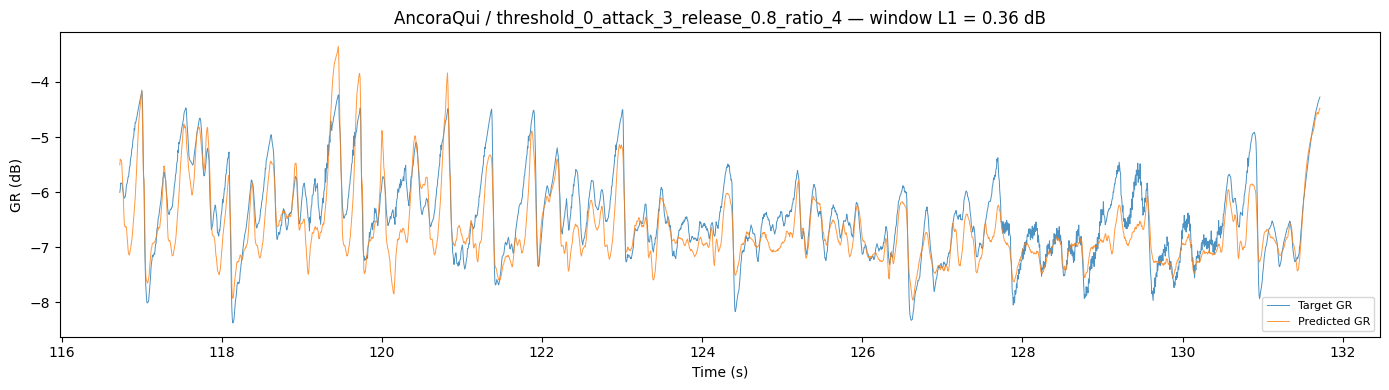

In [11]:
# ── 9. Full-song streaming eval + plot ───────────────────────────────
# Streams whole songs chunked with explicit state carry (the deployment
# path — chunked forward is exact vs one full forward). val = held-out song
# × all settings; test = the external test_ground_truth pairs (their
# exported GR curves serve as labels here — test-only, never trained on).
# The printed full-context GR MAE is directly comparable to the run table.

import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf

best = torch.load(callbacks[0].best_model_path, map_location="cuda", weights_only=False)
system.load_state_dict(best["state_dict"])
system.eval().cuda()
model_e = system.model
print(f"Loaded best checkpoint: {callbacks[0].best_model_path}")

CHUNK = int(10.0 * SAMPLE_RATE) // HOP_SIZE * HOP_SIZE


@torch.no_grad()
def stream_pair(m):
    audio, _ = sf.read(m["dry"], dtype="float32", always_2d=True)
    dry = torch.from_numpy(audio.T)
    if dry.shape[0] > 1:
        dry = dry.mean(dim=0, keepdim=True)
    gr = torch.load(m["gr"], weights_only=False)["gr_db"].float()
    if gr.dim() == 1:
        gr = gr.unsqueeze(0)
    n = min(dry.shape[-1], gr.shape[-1])
    n -= n % HOP_SIZE
    dry, gr = dry[None, ..., :n], gr[None, ..., :n]
    params = torch.tensor(m["params"], dtype=torch.float32)[None].cuda()

    state, preds = None, []
    for o in range(0, n, CHUNK):
        logits, state = model_e(
            dry[..., o : o + CHUNK].cuda(), params, state, return_state=True,
        )
        # the local-avg decode is per-frame, so per-chunk decode == full decode
        preds.append(logits_to_local_avg_db(logits).cpu())
    pred = torch.cat(preds, -1)
    tgt = F.avg_pool1d(gr, HOP_SIZE)
    en = 10 * torch.log10(F.avg_pool1d(dry**2, HOP_SIZE) + 1e-12) > ENERGY_FLOOR_DB
    return pred, tgt, en


for split_name in ("val", "test"):
    errs, wsum = 0.0, 0
    for m in dm.meta[split_name]:
        pred, tgt, en = stream_pair(m)
        e = (pred - tgt).abs()[en]
        errs += float(e.sum())
        wsum += int(en.sum())
        print(f"  {split_name} {m['song']:16s} {m['setting']:45s} "
              f"MAE {float(e.mean()):.3f} dB")
    print(f"{split_name.upper()} full-context GR MAE: {errs / max(wsum, 1):.3f} dB\n")

# -- plot: mid-song window of a val pair, prediction vs target ---------
pick = dm.meta["val"][len(dm.meta["val"]) // 2]
pred, tgt, en = stream_pair(pick)
Tf = pred.shape[-1]
w0, w1 = Tf // 2, Tf // 2 + int(15.0 * SAMPLE_RATE / HOP_SIZE)  # 15 s window
t = np.arange(w0, w1) * HOP_SIZE / SAMPLE_RATE

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t, tgt[0, 0, w0:w1], label="Target GR", alpha=0.8, lw=0.7)
ax.plot(t, pred[0, 0, w0:w1], label="Predicted GR", alpha=0.8, lw=0.7)
l1 = float((pred - tgt).abs()[..., w0:w1][en[..., w0:w1]].mean())
ax.set_title(f"{pick['song']} / {pick['setting']} — window L1 = {l1:.2f} dB")
ax.set_xlabel("Time (s)")
ax.set_ylabel("GR (dB)")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
plot_path = os.path.join(RUN_DIR, "eval_gr_comparison.png")
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
print(f"Saved plot -> {plot_path}")
plt.show()

In [12]:
# ── 10. Detector time constants ──────────────────────────────────────
# Fixed by default in v2: the v1 learnable bank collapsed onto the label's
# RMS-1024 window ((2,12,40,150) → (14.6,15.4,19.1,74.8) ms), losing the
# release timescale. If DETECTOR_LEARNABLE was set, this shows the drift.

print(f"detector τ (ms): init    {list(DETECTOR_TAUS_MS)}")
print(f"                 current {[round(float(v), 1) for v in model_e.detector.taus_ms]}"
      f"  ({'learnable' if DETECTOR_LEARNABLE else 'fixed'})")

detector τ (ms): init    [2.0, 5.0, 11.0, 26.0, 61.0, 144.0, 340.0, 800.0]
                 current [2.0, 5.0, 11.0, 26.0, 61.0, 144.0, 340.0, 800.0]  (fixed)


In [13]:
%load_ext tensorboard
%tensorboard --logdir "{RUN_DIR}/tb"

<IPython.core.display.Javascript object>